# แนะนำสายพันธุ์ดอกไม้ ด้วย Graph (Flower Recommender System)

**แนวคิด:** ผู้ใช้แต่ละคนชื่นชอบดอกไม้บางสายพันธุ์ พร้อมให้คะแนนความชอบ (1-5) → หา "ผู้ใช้ที่รสนิยมใกล้เคียงกัน" → ดูว่าคนเหล่านั้นชอบดอกไม้อะไรอีกที่เรายังไม่เคยเลือก → คำนวณคะแนนแล้วแนะนำกลับมา พร้อมบอก **ความหมายของดอกไม้** ที่แนะนำด้วย



## ผู้ใช้งาน 10 คน (ใช้ชื่อภาษาอังกฤษในกราฟ/โค้ด)
| ชื่อเล่น (ไทย) | ชื่อที่ใช้ในกราฟ/โค้ด |
|---|---|
| แพรว | Praew |
| แก้ว | Kaew |
| มิว | Miu |
| ฝน | Fon |
| ปาล์ม | Palm |
| จอย | Joy |
| ท็อป | Top |
| นุ๊ก |  Nook |
| เกม | Game |
| โบว์ | Bow |

## สายพันธุ์ดอกไม้ 12 ชนิด (ชื่อในกราฟ/โค้ดเป็นภาษาอังกฤษ ความหมายยังเป็นภาษาไทย)

| ชื่อที่ใช้ในกราฟ/โค้ด | ความหมาย (ไทย) |
|---|---|
| Jasmine | ความรักอันบริสุทธิ์ ความกตัญญู |
| Pink Rose | ความรักอันอ่อนโยน ความขอบคุณ |
| Lotus | ความบริสุทธิ์ การหลุดพ้นจากกิเลส |
| Sunflower | ความหวัง พลังบวก |
| White Lily | ความบริสุทธิ์ เกียรติยศ |
| Purple Orchid | ความสง่างาม เสน่ห์ |
| Chrysanthemum | ความสัตย์ซื่อ อายุยืนยาว |
| Red Carnation | ความรักของแม่ |
| Blue Iris | ปัญญา ความหวัง ศรัทธา |
| Red Tulip | ความรักที่สมบูรณ์แบบ |
|Daisy | ความรักบริสุทธิ์ ความสดใสไร้เดียงสา |
|Hydrangea | ความเข้าใจ การขอบคุณจากหัวใจ |

## ข้อมูลความชอบ (พร้อมคะแนน 1-5)

```
Praew → Jasmine (5), Pink Rose (4), Lotus (3)
Kaew  → Jasmine (4), Pink Rose (5), Sunflower (3), White Lily (4)
Miu   → Lotus (5), Purple Orchid (4), Chrysanthemum (3)
Fon   → Sunflower (5), White Lily (4), Blue Iris (4), Red Tulip (3)
Palm  → Purple Orchid (5), Chrysanthemum (4), Red Carnation (5)

Joy → Daisy (5), Pink Rose (4), Jasmine (3)
Top → Daisy (4), Hydrangea (5), Sunflower (3)
Nook → Hydrangea (4), Blue Iris (5)
Game → Red Tulip (4), Daisy (3), Red Carnation (4)
Bow → Hydrangea (3), White Lily (5),Purple Orchid (4)
```

จะเห็นว่า **Praew (แพรว)** กับ **Kaew (แก้ว)** ชอบดอกไม้คล้ายกัน (Jasmine, Pink Rose) แต่ **Kaew** ยังชอบ **Sunflower** และ **White Lily** ที่ Praew ยังไม่เคยเลือก → ระบบอาจแนะนำดอกไม้เหล่านี้ให้ Praew โดยให้น้ำหนักตามคะแนนที่ Kaew ให้ไว้ด้วย

## การออกแบบ Graph

```
Node 2 ประเภท: user, flower
Relationship: PREFERS (มีน้ำหนัก = คะแนนความชอบ)

(User)-[:PREFERS {rating}]->(Flower)

เช่น
(Praew)-[:PREFERS {rating:5}]->(Jasmine)

Python NetworkX:
G.add_edge("Praew", "Jasmine", weight=5)
```

**สร้างด้วย Python บน Google Colab**

In [ ]:
!pip -q install networkx

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

In [ ]:
G = nx.Graph()

In [ ]:
# เพิ่ม node ผู้ใช้ (ใช้ชื่อภาษาอังกฤษ เพื่อให้แสดงผลบนกราฟได้ปกติ)
users = [
    "Praew",
    "Kaew",
    "Miu",
    "Fon",
    "Palm",
    "Joy",
    "Top",
    "Nook",
    "Game",
    "Bow"
]

for user in users:
    G.add_node(
        user,
        node_type="user"
    )

In [ ]:
# เพิ่ม node ดอกไม้ พร้อมความหมาย (ความหมายยังเป็นภาษาไทย เพราะ print ปกติไม่มีปัญหาฟอนต์)
flowers = {
    "Jasmine": "ความรักอันบริสุทธิ์ ความกตัญญู",
    "Pink Rose": "ความรักอันอ่อนโยน ความขอบคุณ",
    "Lotus": "ความบริสุทธิ์ การหลุดพ้นจากกิเลส",
    "Sunflower": "ความหวัง พลังบวก",
    "White Lily": "ความบริสุทธิ์ เกียรติยศ",
    "Purple Orchid": "ความสง่างาม เสน่ห์",
    "Chrysanthemum": "ความสัตย์ซื่อ อายุยืนยาว",
    "Red Carnation": "ความรักของแม่",
    "Blue Iris": "ปัญญา ความหวัง ศรัทธา",
    "Red Tulip": "ความรักที่สมบูรณ์แบบ",
    "Daisy": "ความรักบริสุทธิ์ ความสดใสไร้เดียงสา",
    "Hydrangea": "ความเข้าใจ การขอบคุณจากหัวใจ"
}

for flower, meaning in flowers.items():
    G.add_node(
        flower,
        node_type="flower",
        meaning=meaning
    )

In [ ]:
# ความสัมพันธ์: (user, flower, rating)
preferences = [
    ("Praew", "Jasmine", 5),
    ("Praew", "Pink Rose", 4),
    ("Praew", "Lotus", 3),

    ("Kaew", "Jasmine", 4),
    ("Kaew", "Pink Rose", 5),
    ("Kaew", "Sunflower", 3),
    ("Kaew", "White Lily", 4),

    ("Miu", "Lotus", 5),
    ("Miu", "Purple Orchid", 4),
    ("Miu", "Chrysanthemum", 3),

    ("Fon", "Sunflower", 5),
    ("Fon", "White Lily", 4),
    ("Fon", "Blue Iris", 4),
    ("Fon", "Red Tulip", 3),

    ("Palm", "Purple Orchid", 5),
    ("Palm", "Chrysanthemum", 4),
    ("Palm", "Red Carnation", 5),

    ("Joy", "Daisy", 5),
    ("Joy", "Pink Rose", 4),
    ("Joy", "Jasmine", 3),

    ("Top", "Daisy", 4),
    ("Top", "Hydrangea", 5),
    ("Top", "Sunflower", 3),

    ("Nook", "Hydrangea", 4),
    ("Nook", "Blue Iris", 5),

    ("Game", "Red Tulip", 4),
    ("Game", "Daisy", 3),
    ("Game", "Red Carnation", 4),

    ("Bow", "Hydrangea", 3),
    ("Bow", "White Lily", 5),
    ("Bow", "Purple Orchid", 4)
]

เพิ่มเข้า Graph พร้อมน้ำหนัก (rating) บนเส้นเชื่อม

In [ ]:
for user, flower, rating in preferences:
    G.add_edge(user, flower, weight=rating)

## วาด Graph (แยกสีระหว่าง User และ Flower)

เนื่องจากชื่อ node เป็นภาษาอังกฤษแล้ว จึงไม่ต้องติดตั้งฟอนต์ไทยเพิ่มเติม กราฟจะแสดงผลได้ปกติทันทีบน Colab

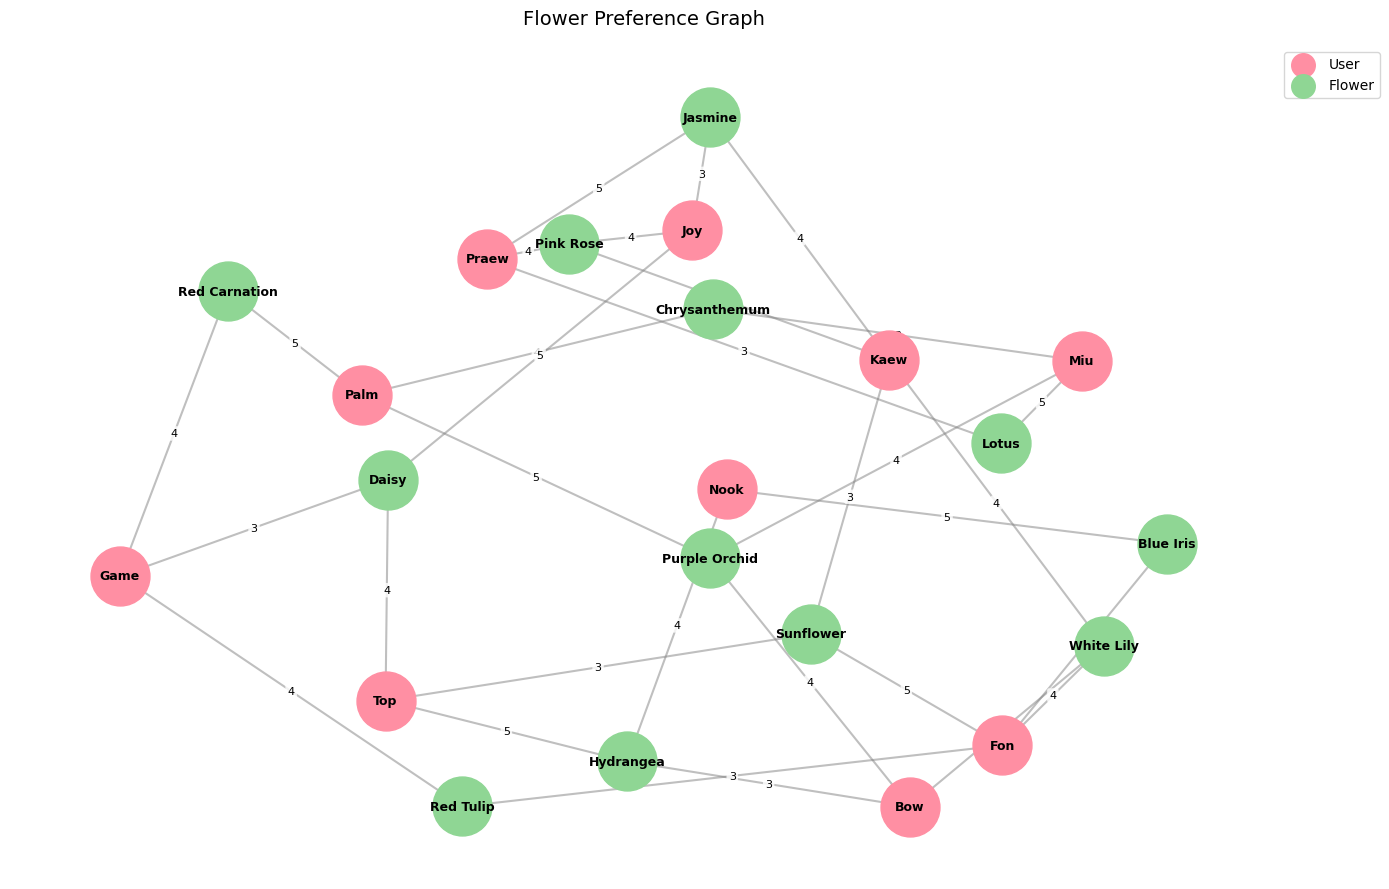

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(14, 9))

# 1. เพิ่มค่า k เพื่อขยายระยะห่างระหว่าง Node ไม่ให้ซ้อนทับกัน
pos = nx.spring_layout(G, k=1.5, seed=7)

user_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "user"]
flower_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "flower"]

# 2. วาด Node
nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_color="#ff8fa3", node_size=1800, label="User")
nx.draw_networkx_nodes(G, pos, nodelist=flower_nodes, node_color="#8fd694", node_size=1800, label="Flower")

# 3. วาดเส้นขอบ (Edge)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.5, edge_color="gray")

# 4. วาดชื่อ Node
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

# 5. ใส่ตัวเลข Weight พร้อมพื้นหลังสีขาว (bbox) และตั้งค่า rotate=False เพื่อให้อ่านง่าย
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=8,
    rotate=False,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
)

# 6. ย้าย Legend ออกไปไว้นอกกราฟ และลดขนาดสัญลักษณ์ลงด้วย markerscale
plt.legend(scatterpoints=1, markerscale=0.4, loc="upper left", bbox_to_anchor=(1, 1), frameon=True)
plt.title("Flower Preference Graph", fontsize=14, pad=15)
plt.axis("off")
plt.tight_layout()
plt.show()




คำถามแรก <br>
1. Fon (ฝน) ชื่นชอบดอกไม้อะไรบ้าง?

In [ ]:
fon_flowers = list(G.neighbors("Fon"))

for flower in fon_flowers:
    rating = G["Fon"][flower]["weight"]
    print(f"{flower} (ให้คะแนน {rating})")

Sunflower (ให้คะแนน 5)
White Lily (ให้คะแนน 4)
Blue Iris (ให้คะแนน 4)
Red Tulip (ให้คะแนน 3)


Neighbor ของ Fon คือ Node ดอกไม้ที่เชื่อมกับ Fon โดยแต่ละเส้นมีน้ำหนัก (rating) กำกับอยู่ด้วย

คำถามที่ 2. หา User ที่รสนิยมใกล้เคียงกับ Fon (ฝน) <br>
Fon ชอบ Sunflower, White Lily, Blue Iris, Red Tulip <br>
หาว่าใครชอบดอกไม้เหล่านี้ด้วยเหมือนกัน

In [ ]:
for flower in G.neighbors("Fon"):

    print("ดอกไม้:", flower)

    for user in G.neighbors(flower):

        if user != "Fon" and G.nodes[user]["node_type"] == "user":
            print("  ผู้ใช้ที่รสนิยมใกล้เคียง:", user)

ดอกไม้: Sunflower
  ผู้ใช้ที่รสนิยมใกล้เคียง: Kaew
  ผู้ใช้ที่รสนิยมใกล้เคียง: Top
ดอกไม้: White Lily
  ผู้ใช้ที่รสนิยมใกล้เคียง: Kaew
  ผู้ใช้ที่รสนิยมใกล้เคียง: Bow
ดอกไม้: Blue Iris
  ผู้ใช้ที่รสนิยมใกล้เคียง: Nook
ดอกไม้: Red Tulip
  ผู้ใช้ที่รสนิยมใกล้เคียง: Game


**สร้าง Recommendation ที่ถ่วงน้ำหนักด้วยคะแนน**

```
แนวคิดคือ
target_user
 ↓
ดอกไม้ที่ target_user ชอบ (พร้อมคะแนนตัวเอง)
 ↓
User อื่นที่ชอบดอกไม้เดียวกัน (พร้อมคะแนนของเขา)
 ↓
ดอกไม้อื่นที่ User เหล่านั้นชอบ ยังไม่เคยเลือก
 ↓
คะแนนแนะนำ = ผลรวม(คะแนนของ user อื่น ต่อดอกไม้นั้น)
 ↓
เรียงคะแนนมาก → น้อย แล้วแนะนำ
```

In [ ]:
def recommend_flowers(G, target_user):

    scores = defaultdict(float)

    liked_flowers = set(G.neighbors(target_user))

    for flower in liked_flowers:

        for similar_user in G.neighbors(flower):

            if similar_user == target_user:
                continue
            if G.nodes[similar_user]["node_type"] != "user":
                continue

            for other_flower in G.neighbors(similar_user):

                if other_flower in liked_flowers:
                    continue

                rating = G[similar_user][other_flower]["weight"]
                scores[other_flower] += rating

    # เรียงจากคะแนนมากไปน้อย
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return ranked

เรียกใช้งานกับผู้ใช้แต่ละคน พร้อมแสดงความหมายของดอกไม้ที่แนะนำ (ความหมายยังเป็นภาษาไทย)

In [ ]:
def show_recommendations(G, target_user):

    print(f"=== แนะนำดอกไม้สำหรับ {target_user} ===")

    results = recommend_flowers(G, target_user)

    if not results:
        print("  ไม่มีดอกไม้ให้แนะนำเพิ่มเติม")
        return

    for flower, score in results:
        meaning = G.nodes[flower]["meaning"]
        print(f"  {flower}  (คะแนน {score:.0f})  → ความหมาย: {meaning}")

    print()

In [ ]:
for user in users:
    show_recommendations(G, user)

=== แนะนำดอกไม้สำหรับ Praew ===
  Daisy  (คะแนน 10)  → ความหมาย: ความรักบริสุทธิ์ ความสดใสไร้เดียงสา
  White Lily  (คะแนน 8)  → ความหมาย: ความบริสุทธิ์ เกียรติยศ
  Sunflower  (คะแนน 6)  → ความหมาย: ความหวัง พลังบวก
  Purple Orchid  (คะแนน 4)  → ความหมาย: ความสง่างาม เสน่ห์
  Chrysanthemum  (คะแนน 3)  → ความหมาย: ความสัตย์ซื่อ อายุยืนยาว

=== แนะนำดอกไม้สำหรับ Kaew ===
  Daisy  (คะแนน 14)  → ความหมาย: ความรักบริสุทธิ์ ความสดใสไร้เดียงสา
  Blue Iris  (คะแนน 8)  → ความหมาย: ปัญญา ความหวัง ศรัทธา
  Hydrangea  (คะแนน 8)  → ความหมาย: ความเข้าใจ การขอบคุณจากหัวใจ
  Lotus  (คะแนน 6)  → ความหมาย: ความบริสุทธิ์ การหลุดพ้นจากกิเลส
  Red Tulip  (คะแนน 6)  → ความหมาย: ความรักที่สมบูรณ์แบบ
  Purple Orchid  (คะแนน 4)  → ความหมาย: ความสง่างาม เสน่ห์

=== แนะนำดอกไม้สำหรับ Miu ===
  Red Carnation  (คะแนน 10)  → ความหมาย: ความรักของแม่
  Jasmine  (คะแนน 5)  → ความหมาย: ความรักอันบริสุทธิ์ ความกตัญญู
  White Lily  (คะแนน 5)  → ความหมาย: ความบริสุทธิ์ เกียรติยศ
  Pink Rose  (คะแนน 4)  → ความหมาย: ความรักอ

In [ ]:
#เรียกใช้งาน
result = recommend_flowers( G, "Praew")
print(result)

[('Daisy', 10.0), ('White Lily', 8.0), ('Sunflower', 6.0), ('Purple Orchid', 4.0), ('Chrysanthemum', 3.0)]


In [ ]:
#เรียกใช้งาน
result = recommend_flowers( G, "Top")
print(result)

[('White Lily', 13.0), ('Pink Rose', 9.0), ('Blue Iris', 9.0), ('Jasmine', 7.0), ('Red Tulip', 7.0), ('Red Carnation', 4.0), ('Purple Orchid', 4.0)]


## สรุป

ระบบแนะนำแบบ Graph นี้ไม่ได้มองแค่ว่า "ดอกไม้ชนิดไหนดัง" แต่มองว่า **"ผู้ใช้คนนี้เชื่อมโยงกับผู้ใช้และดอกไม้คนอื่นอย่างไร"** และยังนำ **น้ำหนักคะแนนความชอบ** มาช่วยจัดอันดับคำแนะนำให้แม่นยำขึ้น พร้อมแนบ **ความหมายของดอกไม้** เพื่อให้คำแนะนำมีคุณค่าทางใจ

ส่วนชื่อ user/flower ที่ใช้ในกราฟและโค้ดเปลี่ยนเป็นภาษาอังกฤษเพื่อให้รันบน Google Colab ได้ทันทีโดยไม่ต้องติดตั้งฟอนต์เพิ่ม ในขณะที่คำอธิบาย คอมเมนต์ และความหมายของดอกไม้ยังคงเป็นภาษาไทยตามเดิม